In [1]:
pip install pandas nltk scikit-learn matplotlib seaborn wordcloud

In [13]:
import pandas as pd
import nltk
import string
import matplotlib.pyplot as plt

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, accuracy_score
from wordcloud import WordCloud

# Download required NLTK datasets
nltk.download('punkt')
nltk.download('stopwords')

nltk.download('punkt_tab')


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [3]:
data = {
    "Review": [
        "Food was delicious and delivery was fast",
        "The pizza was cold and the delivery was late",
        "Excellent customer service and tasty food",
        "Packaging was damaged and food quality was poor",
        "Affordable price and great taste",
        "Delivery was very slow and food arrived cold",
        "Loved the burger and quick service",
        "The food was overpriced and not tasty",
        "Amazing experience with friendly staff",
        "Bad packaging and delayed delivery"
    ],

    "Sentiment": [
        "Positive",
        "Negative",
        "Positive",
        "Negative",
        "Positive",
        "Negative",
        "Positive",
        "Negative",
        "Positive",
        "Negative"
    ]
}

df = pd.DataFrame(data)

print(df.head())

                                            Review Sentiment
0         Food was delicious and delivery was fast  Positive
1     The pizza was cold and the delivery was late  Negative
2        Excellent customer service and tasty food  Positive
3  Packaging was damaged and food quality was poor  Negative
4                 Affordable price and great taste  Positive


In [7]:
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    text = text.lower()

    tokens = word_tokenize(text)

    tokens = [
        word for word in tokens
        if word not in stop_words
        and word not in string.punctuation
    ]

    return " ".join(tokens)

df["Cleaned_Review"] = df["Review"].apply(preprocess_text)

print(df[["Review", "Cleaned_Review"]])

                                            Review  \
0         Food was delicious and delivery was fast   
1     The pizza was cold and the delivery was late   
2        Excellent customer service and tasty food   
3  Packaging was damaged and food quality was poor   
4                 Affordable price and great taste   
5     Delivery was very slow and food arrived cold   
6               Loved the burger and quick service   
7            The food was overpriced and not tasty   
8           Amazing experience with friendly staff   
9               Bad packaging and delayed delivery   

                          Cleaned_Review  
0           food delicious delivery fast  
1               pizza cold delivery late  
2  excellent customer service tasty food  
3    packaging damaged food quality poor  
4           affordable price great taste  
5        delivery slow food arrived cold  
6             loved burger quick service  
7                  food overpriced tasty  
8      amazing exp

In [15]:
vectorizer = CountVectorizer()

X = vectorizer.fit_transform(df["Cleaned_Review"])

y = df["Sentiment"]


In [16]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer()

X = vectorizer.fit_transform(df["Cleaned_Review"])
y = df["Sentiment"]

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [10]:
model = MultinomialNB()

model.fit(X_train, y_train)

predictions = model.predict(X_test)

In [11]:
print("Accuracy:", accuracy_score(y_test, predictions))

print("\nClassification Report:\n")
print(classification_report(y_test, predictions))

Accuracy: 0.5

Classification Report:

              precision    recall  f1-score   support

    Negative       0.50      1.00      0.67         1
    Positive       0.00      0.00      0.00         1

    accuracy                           0.50         2
   macro avg       0.25      0.50      0.33         2
weighted avg       0.25      0.50      0.33         2



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [17]:
new_reviews = [
    "Food was excellent and delivery was quick",
    "The order was delayed and packaging was damaged"
]

new_reviews_clean = [preprocess_text(review) for review in new_reviews]

new_vector = vectorizer.transform(new_reviews_clean)

results = model.predict(new_vector)

for review, sentiment in zip(new_reviews, results):
    print(f"Review: {review}")
    print(f"Predicted Sentiment: {sentiment}\n")

Review: Food was excellent and delivery was quick
Predicted Sentiment: Positive

Review: The order was delayed and packaging was damaged
Predicted Sentiment: Negative



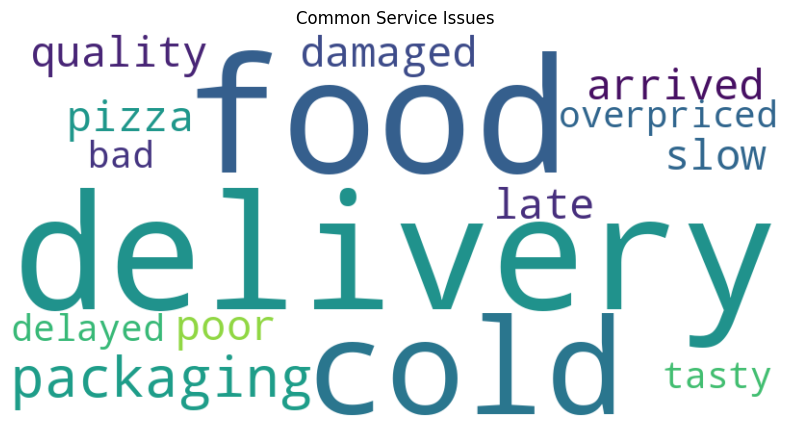

In [18]:
negative_reviews = df[df["Sentiment"] == "Negative"]

text = " ".join(negative_reviews["Cleaned_Review"])

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(text)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title("Common Service Issues")
plt.show()